**This notebook is a copy of the notebook fte_parallel_two_nns.ipynb but it includes training to a longer period of data.**

This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment ACTIVE model to our real, experimental data.

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation.

We initialize the NN based on https://arxiv.org/pdf/2311.15890, and with it we get stable u values.

For the best results we use two separate NNs for the spiking and non-spiking regions.

After the first training (dtw loss with some spike-height punishment) we choose the best 40 models to fine-tune (sse loss).

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx

import jax.random as jr
from typing import List


import equinox as eqx
import flax.nnx as nnx


from voltage_fitting.posthoc_summary_stats import (
    find_spikes,
    spike_count,
    spike_times,
)

Let's see the data!

In [2]:
t_max = 150.0
cut = 1500  # We cut the first 1500 datapoints because this period contains no stimulus

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data
)

t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


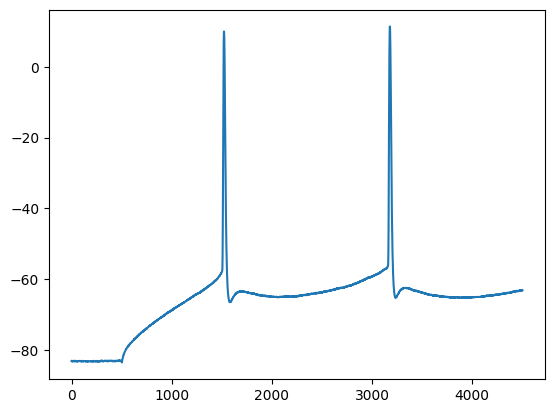

In [3]:
plt.plot(v_data[0])

In [4]:
# Define the single-compartment cell to train
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0])[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


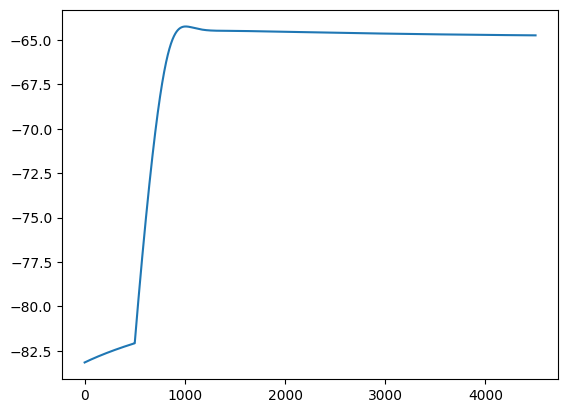

In [5]:
plt.plot(v_single[0])

**How do 100000 simulations of single-compartment cells with random parameters look like? Are there spikes at all? Are they too high?**

In [6]:
from voltage_fitting.loss_util import (
    get_scaled_loss,
)


n_params = 100_000
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_params)
)

def predict(params):
    inv_params = inv_transform_params(params)
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0])[0]
    return get_scaled_loss(v_data[0], v[0], 1.0, 0.05), jnp.abs(jnp.max(v[0])-10.0)

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
losses, diffs = jax.vmap(predict)(opt_params)


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [7]:
print('Minimum loss: ', np.min(losses), ', index: ', np.argmin(losses))
print('Minimum height diff: ', np.min(diffs), ', index: ',np.argmin(diffs))
print(f'There are {jnp.sum(diffs < 50)} spiking simulations.')

Minimum loss:  92.25458073859699 , index:  4151
Minimum height diff:  0.0027496782037630396 , index:  16035
There are 15359 spiking simulations.


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


Text(0.5, 1.0, 'Best height')

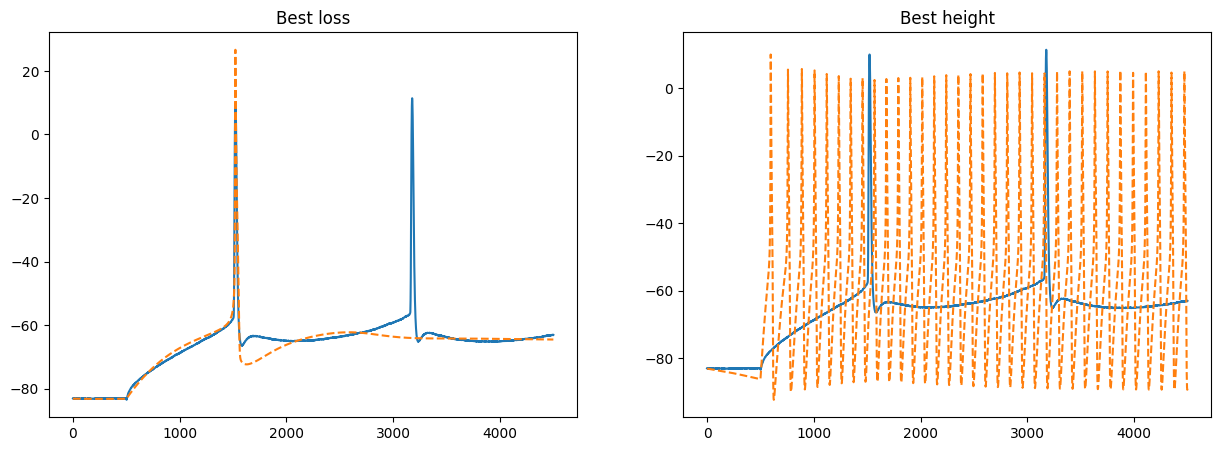

In [8]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
inv_params = inv_transform_params(opt_params[np.argmin(losses)])
    
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
v = simulate_single(inv_params, v_data[0])[0]


fig, axs = plt.subplots(1,2, figsize = (15,5))

axs[0].plot(v_data[0])
axs[0].plot(v[0], linestyle='--')
axs[0].set_title("Best loss")

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
inv_params = inv_transform_params(opt_params[np.argmin(diffs)])
    
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
v = simulate_single(inv_params, v_data[0])[0]

axs[1].plot(v_data[0])
axs[1].plot(v[0], linestyle='--')
axs[1].set_title("Best height")

**Initialization of the NNs**

In [9]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    sample_eigenvalues_on_circle,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices,
)

key = jax.random.PRNGKey(0)
dt = 0.025
u_dimension = 8

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   
    h=dt,
    u_dim=u_dimension,
    use_complex=True
)

print("Sampled Eigenvalues:")
for e in eigs:
    print(e, ", scaled with dt: ", dt*e)

Sampled Eigenvalues:
(-42.141613528976286-22.98417698424073j) , scaled with dt:  (-1.0535403382244073-0.5746044246060182j)
(-42.141613528976286+22.98417698424073j) , scaled with dt:  (-1.0535403382244073+0.5746044246060182j)
(-8.516035334431441+15.86861961008248j) , scaled with dt:  (-0.21290088336078605+0.396715490252062j)
(-8.516035334431441-15.86861961008248j) , scaled with dt:  (-0.21290088336078605-0.396715490252062j)
(-21.545506252691013-34.14736393037374j) , scaled with dt:  (-0.5386376563172753-0.8536840982593437j)
(-21.545506252691013+34.14736393037374j) , scaled with dt:  (-0.5386376563172753+0.8536840982593437j)
(-36.88311383073451-19.00424583475928j) , scaled with dt:  (-0.9220778457683627-0.47510614586898203j)
(-36.88311383073451+19.00424583475928j) , scaled with dt:  (-0.9220778457683627+0.47510614586898203j)


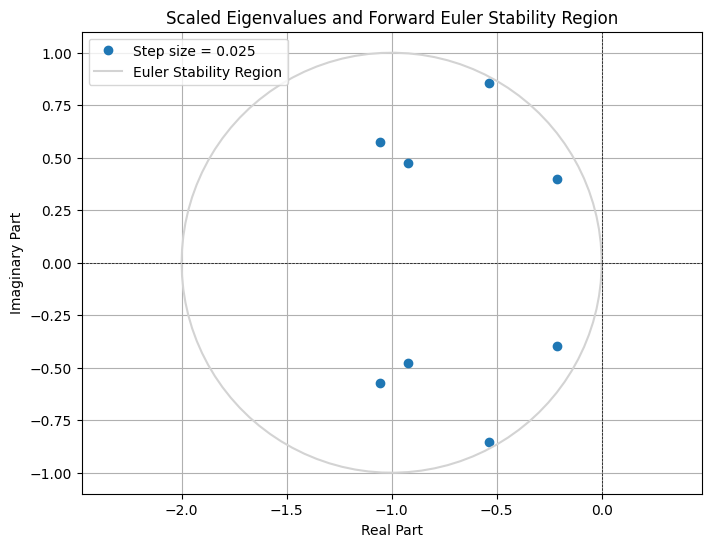

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

Now we make the Lambda, Pi and W matrices based on the paper

In [11]:
num_layers = 3
layer_shapes = [(u_dimension + 1, 32), (32, 16), (16, u_dimension)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

In [12]:
# Checking the eigenvalues of the generated initialization
jnp.linalg.eigvals(W_matrices[2]@W_matrices[1]@W_matrices[0][:, :u_dimension])

Array([-42.14161353+22.98417698j, -42.14161353-22.98417698j,
       -21.54550625+34.14736393j, -21.54550625-34.14736393j,
       -36.88311383+19.00424583j, -36.88311383-19.00424583j,
        -8.51603533+15.86861961j,  -8.51603533-15.86861961j],      dtype=complex128)

**Define the NNs**

In [13]:
# Possible normalization functions
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

In [14]:
class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)


        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)
    
class DoubleCorrectionModel(eqx.Module):
    spike_neural_net: eqx.Module
    spike_readout_net: eqx.Module
    nospike_neural_net: eqx.Module
    nospike_readout_net: eqx.Module
    channel_params_normal: jnp.ndarray

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.spike_neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.spike_readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.nospike_neural_net = SimpleNeuralNet(key=k3, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.nospike_readout_net = ReadoutNet(key=k4, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)


**Define the simulation and the loss**

In [15]:
dt = 0.025
dv_treshold = 0.5


def simulate_full_trace(spike_neural_net, spike_readout_net, nospike_neural_net, nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr = None):
    def cond_fn(carry):
        t, _, _, _, diff, _ = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff, prev_voltage = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        #voltage_normalized = softsign_transform(voltage)
        #voltage_normalized = tempered_tanh(voltage)


        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        # Spike/Nospike?
        dv = jnp.abs(voltage - prev_voltage)
        use_spike_net = dv > dv_treshold
        
        # Compute add_current using spike/nospike NNs
        neural_net_output = jax.lax.cond(use_spike_net, lambda: spike_neural_net(inputs), lambda: nospike_neural_net(inputs))
        u_time_constant = jax.lax.cond(use_spike_net, lambda: spike_u_time_constant, lambda: nospike_u_time_constant)
        u_new = u + dt*neural_net_output / u_time_constant

        readout_net_output = jax.lax.cond(use_spike_net, lambda: spike_readout_net(u_new), lambda: nospike_readout_net(u_new))
        add_current = readout_net_output.squeeze()
        



        total_current = current[t] + add_current * added_curr_std
        state, rec = step_fn(state, total_current)
        rec_voltage = rec[0]



      
        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(neural_net_output)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses), new_diff, voltage)


    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses), 0.0, initial_state["v"][0].squeeze())

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses), _, _ = final_carry

    return recs, adds, us, nn_reses

In [16]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr=300, dtw_reg = 1.0, spike_reg = 0.0, spike_times_reg = 0.0, sse_reg = 0.0, add_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params)

    # Run simulation
    preds, additional_currents, _, _ = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))
    dtw_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    ##########
    # Trying to change the loss function to include spike counts and spike times
    ##########

    noise = np.random.randn(len(preds)) * 1e-2
    preds_spikes = find_spikes(preds + noise, None, None, thr = -20.0)

    noise = np.random.randn(len(v_data)) * 1e-2
    v_data_spikes = find_spikes(v_data + noise, None, None, thr = -20.0)

    spike_times_pred = spike_times(preds_spikes)
    spike_times_data = spike_times(v_data_spikes)

    spike_times_loss = (spike_times_pred[0] - spike_times_data[0]) ** 2 + (spike_times_pred[1] - spike_times_data[1]) ** 2 + (spike_times_pred[2] - spike_times_data[2]) ** 2 + (spike_times_pred[3] - spike_times_data[3]) ** 2

    spike_count_loss = jnp.abs(spike_count(preds_spikes) - spike_count(v_data_spikes)) ** 2
    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))

    ##########
    
    return dtw_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg + spike_times_loss * spike_times_reg + add_loss * add_reg

**Initialize and train**

In [17]:
u_dimension = 8
np.random.seed(42)
n_particles = 300

key1 = jax.random.PRNGKey(0)
key2 = jax.random.PRNGKey(1)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)

# Different, random u_time_constant vectors
log_uniform_samples = jax.random.uniform(key1, shape=(u_dimension,), minval=np.log(1), maxval=np.log(100.0))
nospike_u_time_constant = jnp.exp(log_uniform_samples)

log_uniform_samples = jax.random.uniform(key2, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
spike_u_time_constant = jnp.exp(log_uniform_samples)

added_curr_std = 1.0/10.0


thr = None


# Setup for learning rate scheduler
initial_lr = 15e-4
decay_factor = 0.99 
transition_steps = 1  # decay after every epoch
decay_start = 100 
decay_end = 250 

# Initialize n_particles different parameter sets
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(key, init_params, u_dimension, W_matrices, epsilon):
    model = DoubleCorrectionModel(
        key=key,
        init_params=init_params,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model


models = jax.vmap(initialize_model, in_axes=(0, 0, None, None, None))(
    keys, opt_params, u_dimension, W_matrices, epsilon
)

# Scheduler
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

# Possible optimizers
adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(optax.scale_by_lbfgs(memory_size = 6), optax.scale(-1e-3))
adamw_optimizer = optax.adamw(learning_rate=custom_schedule, weight_decay=1e-4)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adamw_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)


# Loss for optimization and fine-tuning
def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 1.0, spike_reg = 1.0, spike_times_reg= 0.0, sse_reg = 0.0, add_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 0.0, spike_reg = 0.0, spike_times_reg = 0.0, sse_reg = 1.0, add_reg = 0.0)
        return loss


grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))


# Set up the cell
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

In [18]:
# Normalizing, scaling or clipping gradients
def clip_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling
    return jax.tree_util.tree_map(clip_leaf, grads)

def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads

def clip_network_gradients(grads, max_norm=1.0, eps=1e-8):
    def clip_leaf(grad):
        if grad.ndim < 2:
            return grad  # Skip biases or scalars
        flat = grad.reshape((grad.shape[0], -1))
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    def clip_net(net_grads):
        return jax.tree_util.tree_map(clip_leaf, net_grads)

    grads = eqx.tree_at(lambda g: g.spike_neural_net, grads, clip_net(grads.spike_neural_net))
    grads = eqx.tree_at(lambda g: g.spike_readout_net, grads, clip_net(grads.spike_readout_net))
    grads = eqx.tree_at(lambda g: g.nospike_neural_net, grads, clip_net(grads.nospike_neural_net))
    grads = eqx.tree_at(lambda g: g.nospike_readout_net, grads, clip_net(grads.nospike_readout_net))

    return grads

def normalize_gradients(grads, beta=1.0, eps=1e-8):
    def normalize_leaf(grad):
        norm = jnp.linalg.norm(grad, axis=1, keepdims=True)
        return grad / (norm ** beta + eps)

    grads = jax.tree_util.tree_map(normalize_leaf, grads)
    return grads

def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_spike, lr_nospike, lr_channel):
    def scale_tree(tree, factor):
        return jax.tree_util.tree_map(lambda x: x * factor, tree)

    grads_scaled = grads

    grads_scaled = eqx.tree_at(lambda g: g.spike_neural_net, grads_scaled,
                            scale_tree(grads.spike_neural_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.spike_readout_net, grads_scaled,
                            scale_tree(grads.spike_readout_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_neural_net, grads_scaled,
                            scale_tree(grads.nospike_neural_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_readout_net, grads_scaled,
                            scale_tree(grads.nospike_readout_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.channel_params_normal, grads_scaled,
                            grads.channel_params_normal * lr_channel)

    return grads_scaled

In [19]:
num_epochs = 200
mean_losses = []

# Storing the best models and their losses during training
best_losses = jnp.full((1,), jnp.inf)
best_models = models  # Start with the initial models as best
grads_list = []
model_snapshots = []

for epoch in range(num_epochs):

    loss, grads = grad_fn(models)
    grads_list.append(grads)
   
    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_spike=10, lr_nospike = 1e-2, lr_channel=1.0)
    grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)



    improved = loss < best_losses
    best_losses = jnp.where(improved, loss, best_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_models = jax.tree_util.tree_map(replace_if_improved, models, best_models)

    mask = ~jnp.isnan(loss)
    mean_loss = jnp.sum(loss[mask]) / jnp.sum(mask)
    mean_losses.append(mean_loss)

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)
    model_snapshots.append(jax.tree_util.tree_map(lambda x: x.copy(), models))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {mean_loss:.6f}, Median Loss {jnp.median(loss[mask]):.6f}, Min Loss: {jnp.min(loss[mask]):.6f}")

        # print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.bias, axis=1)),
        #   jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.bias, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 427.706300, Median Loss 398.227575, Min Loss: 202.275455
Epoch 10, Mean Loss: 357.046790, Median Loss 318.820652, Min Loss: 193.099526
Epoch 20, Mean Loss: 321.212512, Median Loss 262.935674, Min Loss: 167.981167
Epoch 30, Mean Loss: 322.817414, Median Loss 238.231541, Min Loss: 154.833578
Epoch 40, Mean Loss: 305.168340, Median Loss 231.461893, Min Loss: 192.388793
Epoch 50, Mean Loss: 312.938323, Median Loss 223.883234, Min Loss: 192.320354
Epoch 60, Mean Loss: 315.775900, Median Loss 218.847183, Min Loss: 192.276834
Epoch 70, Mean Loss: 313.701284, Median Loss 213.401519, Min Loss: 192.265592
Epoch 80, Mean Loss: 311.871555, Median Loss 210.125108, Min Loss: 189.387708
Epoch 90, Mean Loss: 306.718789, Median Loss 206.515885, Min Loss: 182.417935
Epoch 100, Mean Loss: 304.719729, Median Loss 203.559255, Min Loss: 187.414153
Epoch 110, Mean Loss: 301.586899, Median Loss 200.278993, Min Loss: 173.718656
Epoch 120, Mean Loss: 302.176203, Median Loss 198.475258, Min L

In [20]:
nan_mask = jnp.isnan(grads_list[num_epochs-1].channel_params_normal)

# Get indices where the mask is True
nan_indices = jnp.argwhere(nan_mask)
print("Not successfully trained models:", int(len(nan_indices)/15))

Not successfully trained models: 3


**Let's see the 10 best models**

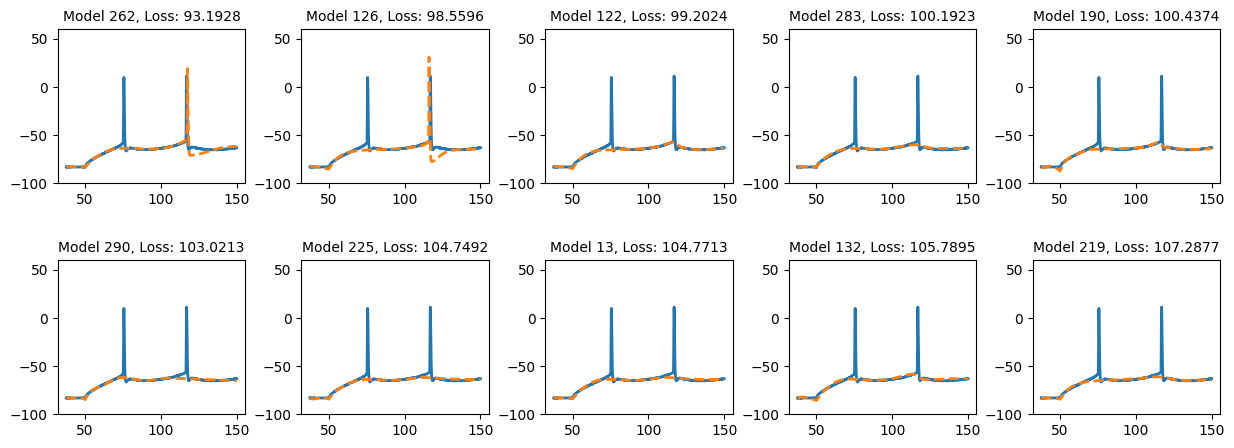

In [ ]:
#t=150.0, reg = 0
inds = np.argsort(best_losses)

ten_best_preds = []
ten_best_losses = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        ten_best_preds.append(final_preds)
        ten_best_losses.append(best_losses[inds[i*5+j]])
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

np.save("../results/longer_ten_best_preds.npy", ten_best_preds)
np.save("../results/longer_ten_best_losses.npy", ten_best_losses)

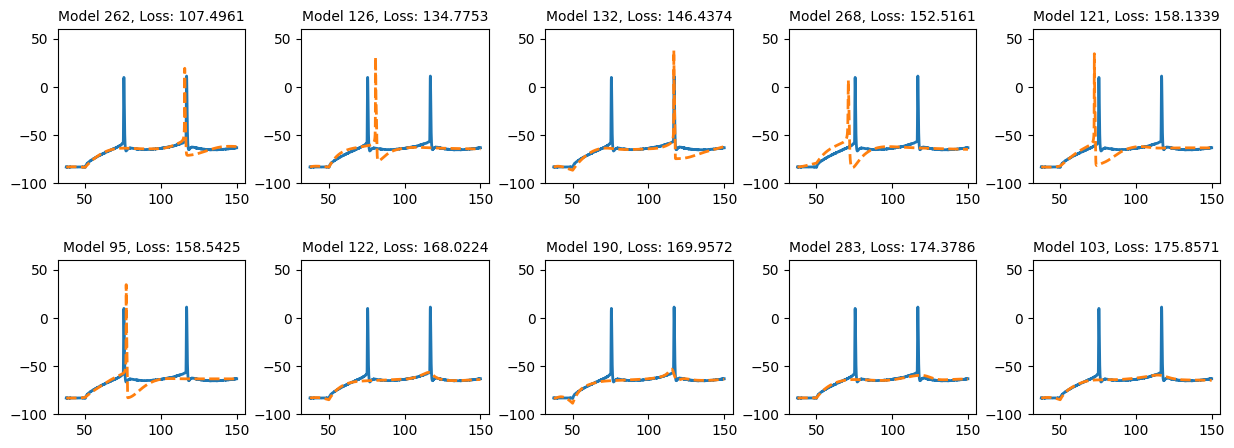

In [ ]:
#t = 150.0, spike_reg = 1.0
inds = np.argsort(best_losses)

ten_best_preds = []
ten_best_losses = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        ten_best_preds.append(final_preds)
        ten_best_losses.append(best_losses[inds[i*5+j]])
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

np.save("../results/longer_ten_best_preds_reg.npy", ten_best_preds)
np.save("../results/longer_ten_best_losses_reg.npy", ten_best_losses)
np.save("../results/v_data_longer.npy", v_data)

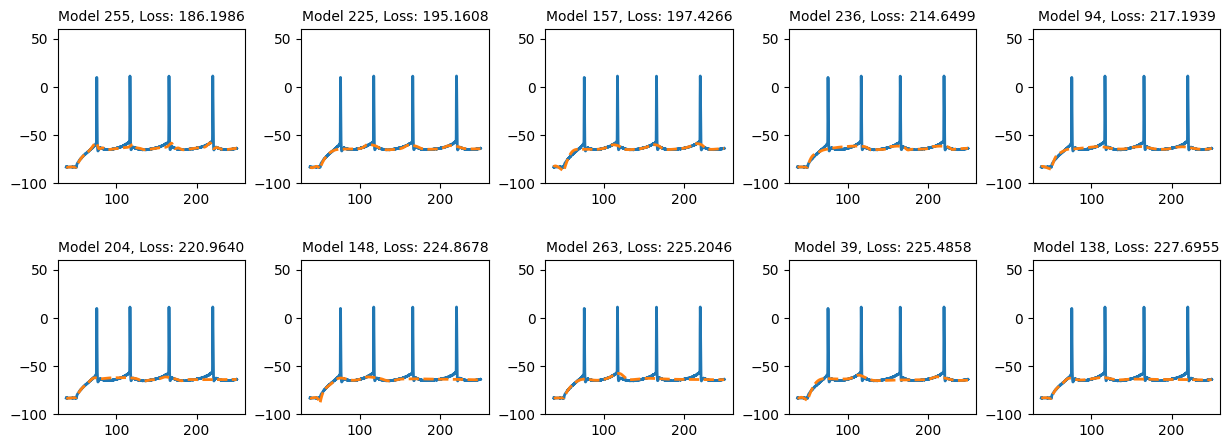

In [ ]:
#t=250.0, reg = 0
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**Problem: If I don't tweak (add regularization to) the loss, the best results don't have any spikes**

**Checking one prediction:**

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


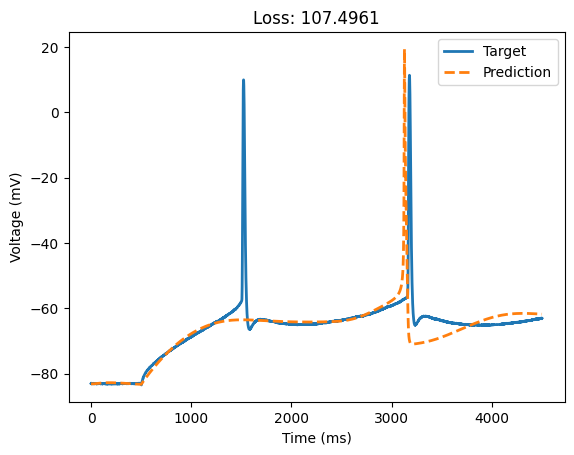

In [22]:
idx = 0
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
)

loss = simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])


Text(0.5, 1.0, 'Additional current')

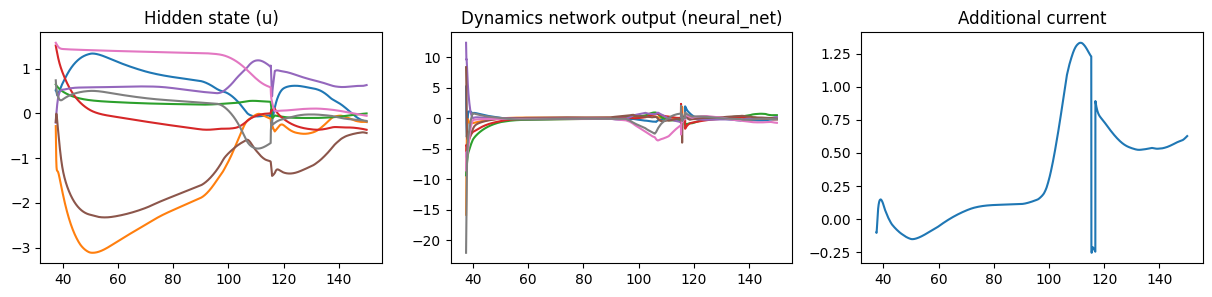

In [23]:
fig, axs = plt.subplots(1,3, figsize = (15,3))
axs[0].plot(time_vec, final_us)
axs[0].set_title("Hidden state (u)")
axs[1].plot(time_vec, final_nn_reses)
axs[1].set_title("Dynamics network output (neural_net)")
axs[2].plot(time_vec, final_additional_currents)
axs[2].set_title("Additional current")

**What are the channel parameters after training?**

Number of parameters: 15


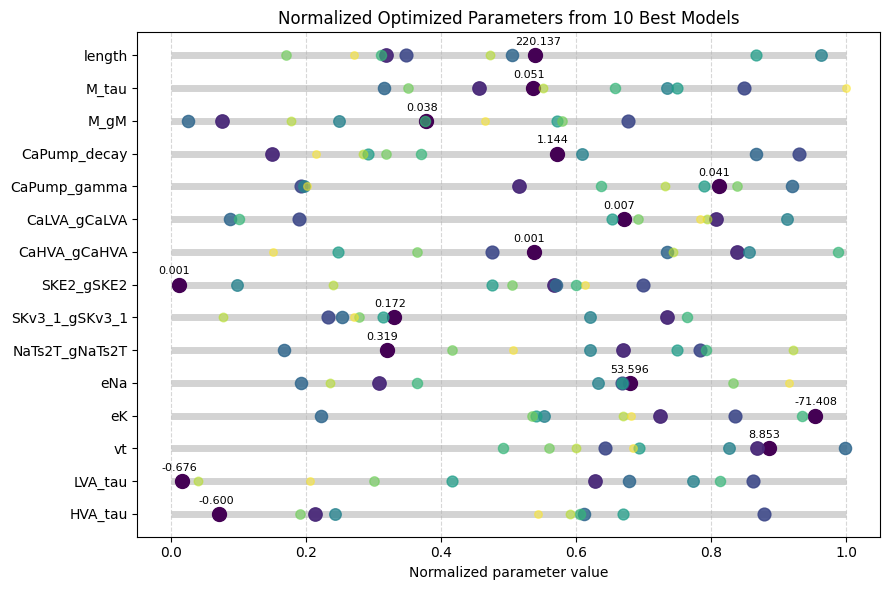

In [24]:
names, lower, upper = get_bounds()

opt_inv_params_list = []
for i in range(10):
    model = jax.tree_util.tree_map(lambda x: x[inds[i]], best_models)
    opt_inv_params = inv_transform_params(model.channel_params_normal)
    opt_inv_params_list.append(opt_inv_params)

param_matrix = np.stack(opt_inv_params_list)

normalized_params = (param_matrix - lower) / (upper - lower)
normalized_params = np.clip(normalized_params, 0, 1)

fig, ax = plt.subplots(figsize=(9, 6))
indices = np.arange(len(opt_inv_params))

# Draw the [0, 1] range
ax.hlines(indices, 0, 1, color='lightgray', linewidth=5, zorder=1)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
colors = plt.cm.Pastel1(np.linspace(0, 1, 10))
colors = plt.cm.viridis(np.linspace(0.0, 1.0, 10))
sizes = np.linspace(100, 30, 10)
alphas = np.linspace(1.0, 0.5, 10)


# Plot all models
for j in range(10):
    ax.scatter(normalized_params[j], indices, color=colors[j], s=sizes[j], alpha = alphas[j], label=f'Model {j+1}', zorder=2)

# Annotate only the best model (j == 0)
for k in range(len(names)):
    x = normalized_params[0, k]
    y = k
    val = param_matrix[0, k]
    ax.text(x - 0.03, y + 0.4, f"{val:.3f}", fontsize=8, color='k', va='center')


ax.set_yticks(indices)
ax.set_yticklabels(names)
ax.set_xlim(-0.05, 1.05)
ax.set_xlabel("Normalized parameter value")
ax.set_title("Normalized Optimized Parameters from 10 Best Models")
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

**Fine-tuning the best 40 models with MSE loss**

In [25]:
top_k = 40
top_k_inds = inds[:top_k]
top_k_models = jax.tree_util.tree_map(lambda x: x[top_k_inds], best_models)
top_k_losses = jnp.full((top_k,), jnp.inf)

fine_tune_lr = 1e-4 
decay_start = 100
decay_end = 200


fine_schedule = optax.exponential_decay(
    init_value=fine_tune_lr,
    transition_steps=1,
    decay_rate=0.99,
    staircase=True,
)
def fine_custom_schedule(step):
    # Epochs before decay_start → constant
    lr = fine_tune_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        fine_tune_lr,
        fine_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = fine_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

fine_optimizer = optax.adam(fine_custom_schedule)
# fine_optimizer = optax.sgd(learning_rate=1e-8, momentum=0.9)
# fine_optimizer = optax.chain(
#             optax.scale_by_lbfgs(memory_size = 8), #8
#             optax.scale(-1e-3), #0.3
#         )

fine_optimizer_states = jax.vmap(lambda m: fine_optimizer.init(eqx.filter(m, eqx.is_inexact_array)))(top_k_models)

num_fine_epochs = 300
fine_mean_losses = []
fine_best_models = top_k_models
fine_best_losses = top_k_losses

for epoch in range(num_fine_epochs):

    loss, grads = fine_grad_fn(top_k_models)

    #grads = scale_grads(grads, lr_spike=10.0, lr_nospike = 1e-2, lr_channel=1.0)
    
    grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)

    improved = loss < fine_best_losses
    fine_best_losses = jnp.where(improved, loss, fine_best_losses)
    fine_best_models = jax.tree_util.tree_map(replace_if_improved, top_k_models, fine_best_models)

    updates, fine_optimizer_states = jax.vmap(lambda g, s, m: fine_optimizer.update(g, s, m, step=epoch))(grads, fine_optimizer_states, top_k_models)
    top_k_models = jax.vmap(eqx.apply_updates)(top_k_models, updates)

    fine_mean_losses.append(jnp.mean(loss))

    if epoch % 10 == 0:
        print(f"Fine-tune epoch {epoch}, Mean Loss: {jnp.mean(loss):.6f}, Median Loss {jnp.median(loss):.6f}, Min Loss: {jnp.min(loss):.6f}")
        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.bias, axis=1)))


/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Fine-tune epoch 0, Mean Loss: 238039.030078, Median Loss 215154.726562, Min Loss: 171797.187500
9.99999999999998 6.955731037687551 9.999999999989159 9.328859236005504 9.99999999998553 8.202095883121446 9.999999999997918 4.229804805014988 9.999999999618817 9.999999999960767 9.999999999825356 6.782833348747742 9.999999999999964 8.506275643277233 9.999999999999956 9.112404733463972 10.0 6.757316587931235 9.999999999999906 9.999999999999986 9.999999999999948
Fine-tune epoch 10, Mean Loss: 222934.755078, Median Loss 210557.234375, Min Loss: 178889.640625
9.999999999999998 6.696205416143047 9.99999999999236 9.43819908376983 9.999999999992092 8.106764236366098 9.999999999998142 7.905713976806476 9.99999999976895 9.999999999991951 9.999999999894051 7.037102495049278 9.999999999999988 8.174904179798357 9.999999999999988 8.20542516255835 10.0 9.06665009768706 9.999999999999982 10.0 9.999999999999993
Fine-tune epoch 20, Mean Loss: 226728.781250, Median Loss 209962.539062, Min Loss: 130716.062500


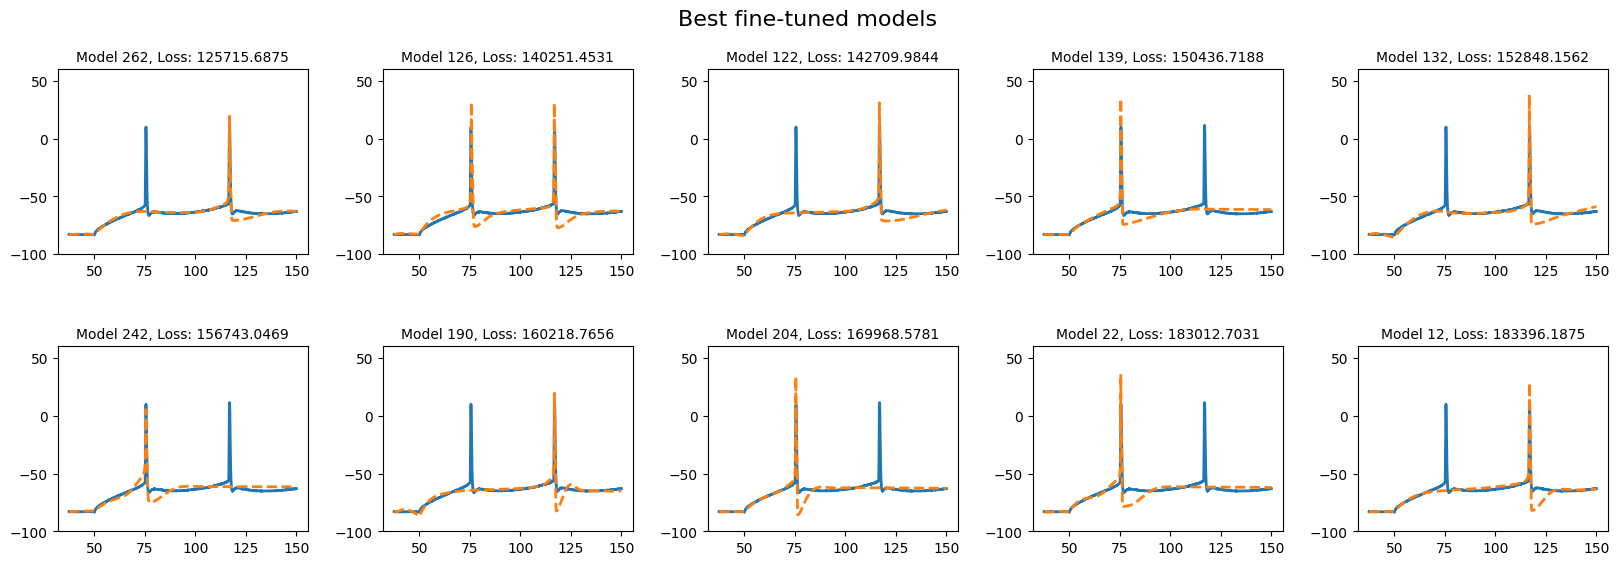

In [ ]:
fine_inds = np.argsort(fine_best_losses)
fig, axs = plt.subplots(2,5, figsize = (20,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle("Best fine-tuned models", fontsize=16)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[fine_inds[i*5+j]], fine_best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
            model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[fine_inds[i*5+j]]}, Loss: {fine_best_losses[fine_inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


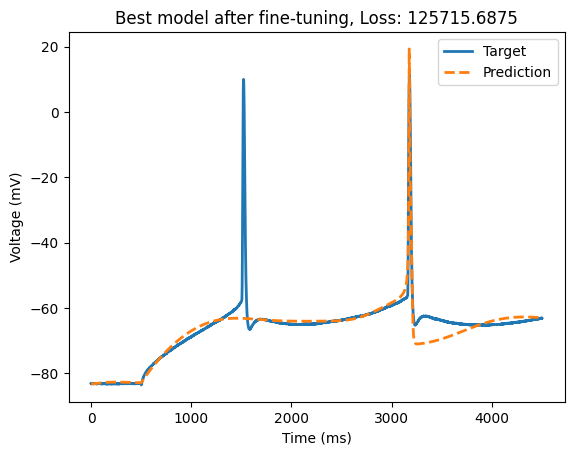

In [27]:
idx = 0

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[fine_inds[idx]], fine_best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
)

loss = fine_simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Best model after fine-tuning, Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])

Text(0.5, 1.0, 'Additional current')

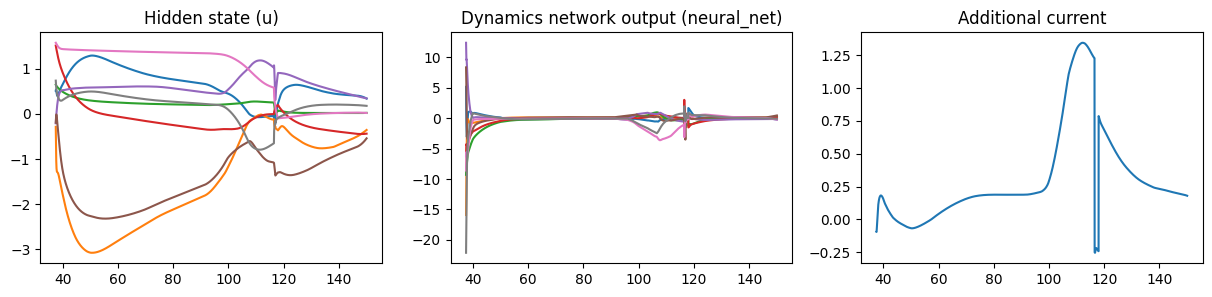

In [28]:
fig, axs = plt.subplots(1,3, figsize = (15,3))
axs[0].plot(time_vec, final_us)
axs[0].set_title("Hidden state (u)")
axs[1].plot(time_vec, final_nn_reses)
axs[1].set_title("Dynamics network output (neural_net)")
axs[2].plot(time_vec, final_additional_currents)
axs[2].set_title("Additional current")


Number of parameters: 15


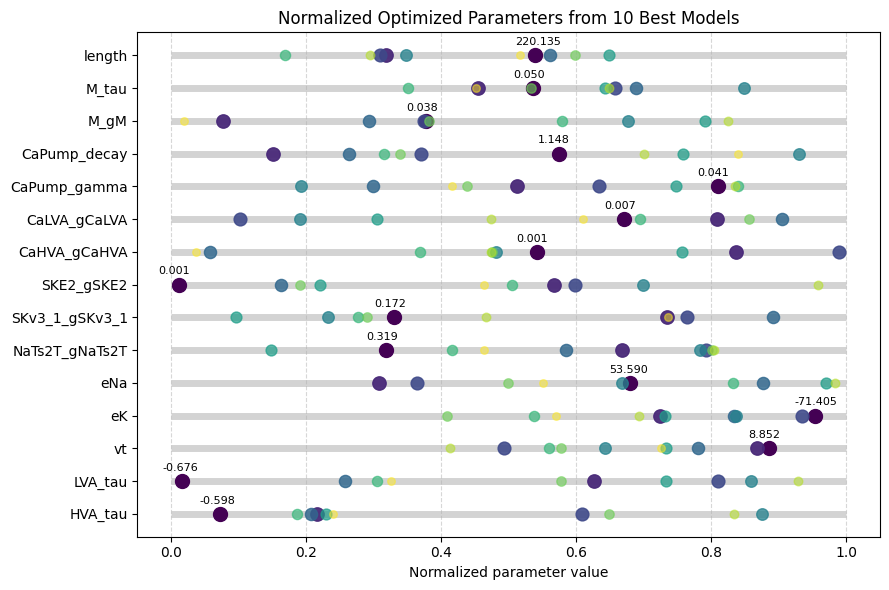

In [29]:
names, lower, upper = get_bounds()

opt_inv_params_list = []
for i in range(10):
    model = jax.tree_util.tree_map(lambda x: x[fine_inds[i]], fine_best_models)
    opt_inv_params = inv_transform_params(model.channel_params_normal)
    opt_inv_params_list.append(opt_inv_params)

param_matrix = np.stack(opt_inv_params_list)

normalized_params = (param_matrix - lower) / (upper - lower)
normalized_params = np.clip(normalized_params, 0, 1)

fig, ax = plt.subplots(figsize=(9, 6))
indices = np.arange(len(opt_inv_params))

# Draw the [0, 1] range
ax.hlines(indices, 0, 1, color='lightgray', linewidth=5, zorder=1)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
colors = plt.cm.Pastel1(np.linspace(0, 1, 10))
colors = plt.cm.viridis(np.linspace(0.0, 1.0, 10))
sizes = np.linspace(100, 30, 10)
alphas = np.linspace(1.0, 0.5, 10)


# Plot all models
for j in range(10):
    ax.scatter(normalized_params[j], indices, color=colors[j], s=sizes[j], alpha = alphas[j], label=f'Model {j+1}', zorder=2)

# Annotate only the best model (j == 0)
for k in range(len(names)):
    x = normalized_params[0, k]
    y = k
    val = param_matrix[0, k]
    ax.text(x - 0.03, y + 0.4, f"{val:.3f}", fontsize=8, color='k', va='center')


ax.set_yticks(indices)
ax.set_yticklabels(names)
ax.set_xlim(-0.05, 1.05)
ax.set_xlabel("Normalized parameter value")
ax.set_title("Normalized Optimized Parameters from 10 Best Models")
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()